<a href="https://colab.research.google.com/github/Vrinda-2004/Assessmenttest/blob/main/intermediate_assessment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv("/content/train_LZdllcl.csv")
test_df = pd.read_csv("/content/test_2umaH9m.csv")
sample_df = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

In [4]:
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [5]:
test_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [6]:
sample_df.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [8]:
train_df.shape

(54808, 14)

In [14]:
print("Testing Dataset Shape :", test_df.shape)
print("Sample Submission Shape :", sample_df.shape)

Testing Dataset Shape : (23490, 13)
Sample Submission Shape : (23490, 2)


In [10]:
train_df.columns


Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')

In [15]:
test_df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [16]:
train_df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [12]:
train_df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [17]:
missing_percentage = (train_df.isnull().sum()) / len(train_df) * 100
missing_percentage.sort_values(ascending = False)

,0
previous_year_rating,7.524449
education,4.395344
department,0.000000
region,0.000000
gender,0.000000
employee_id,0.000000
recruitment_channel,0.000000
no_of_trainings,0.000000
age,0.000000
length_of_service,0.000000


In [19]:
train_df.duplicated().sum()

np.int64(0)

In [20]:
train_df.nunique()

,0
employee_id,54808
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,10
age,41
previous_year_rating,5
length_of_service,35


In [23]:
numerical_columns = train_df.select_dtypes(['int64','float64']).columns
categorical_columns = train_df.select_dtypes(['object']).columns
print(numerical_columns)
print(categorical_columns)

Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')
Index(['department', 'region', 'education', 'gender', 'recruitment_channel'], dtype='object')


In [24]:
train_df['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


In [26]:
train_df['is_promoted'].value_counts(normalize = True) * 100
# here we can see one sample has far more difference than other. so, its an imbalanced dataset.

,proportion
is_promoted,
0,91.482995
1,8.517005


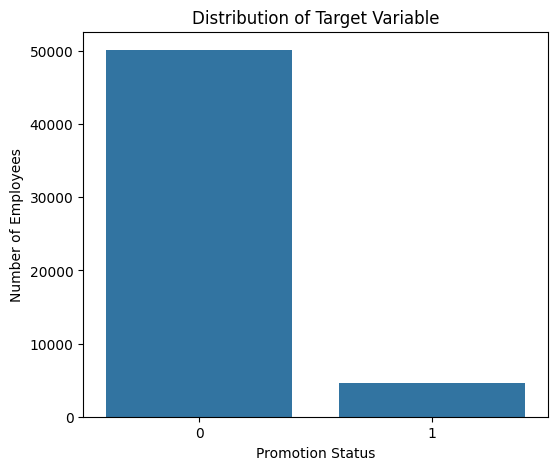

In [29]:
# target variable distribution
plt.figure(figsize=(6,5))

sns.countplot(x='is_promoted', data=train_df)

plt.title("Distribution of Target Variable")
plt.xlabel("Promotion Status")
plt.ylabel("Number of Employees")

plt.show()

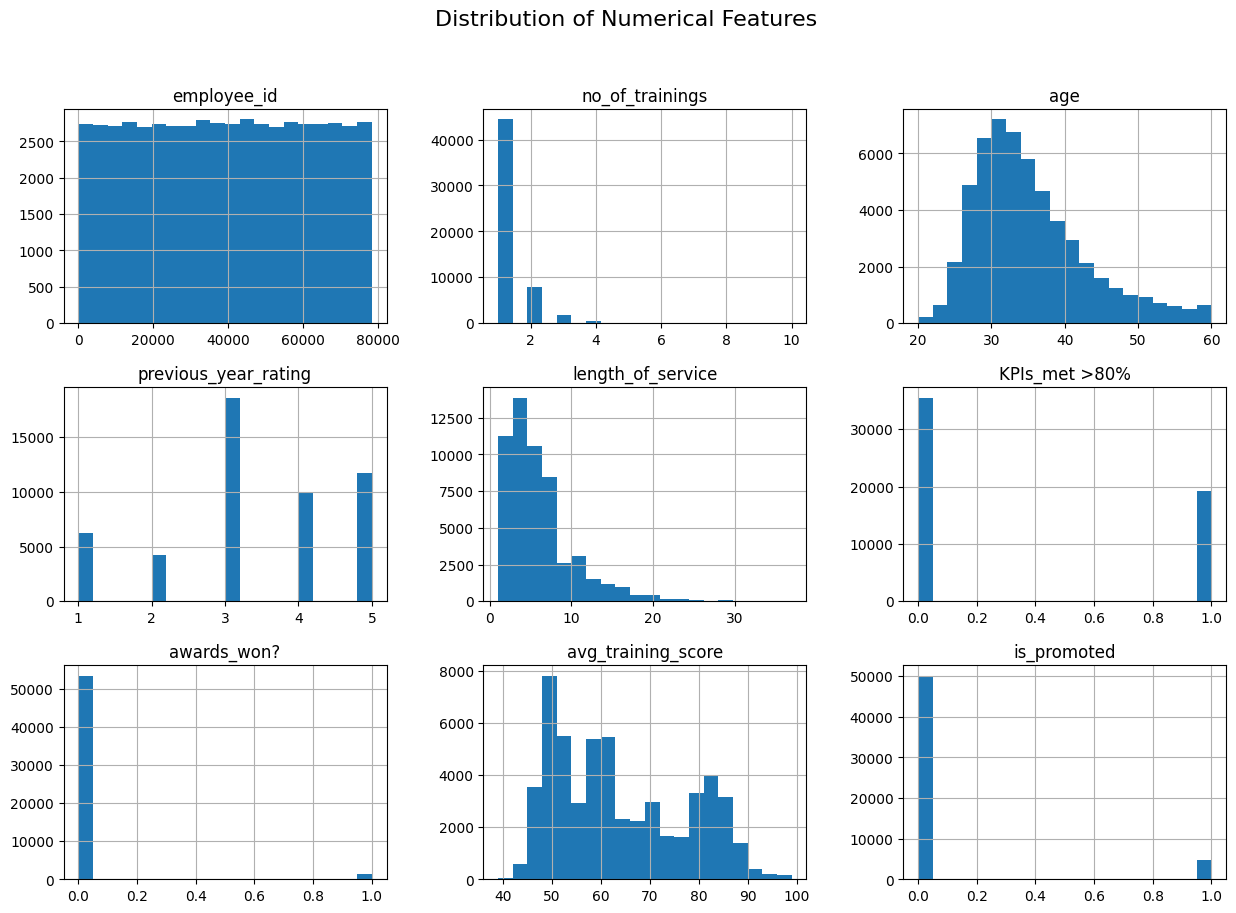

In [28]:
# histograms for numerical features

train_df.hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

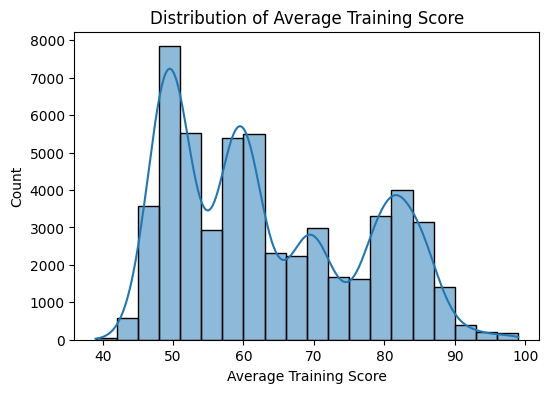

In [30]:
plt.figure(figsize=(6, 4))
sns.histplot(train_df["avg_training_score"], bins=20, kde=True)
plt.title("Distribution of Average Training Score")
plt.xlabel("Average Training Score")
plt.ylabel("Count")
plt.show()

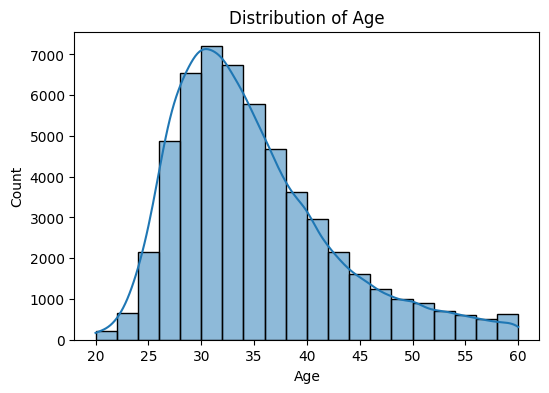

In [31]:
plt.figure(figsize=(6, 4))
sns.histplot(train_df["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

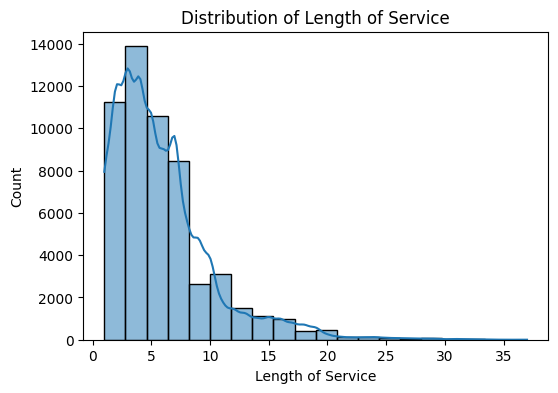

In [32]:
plt.figure(figsize=(6, 4))
sns.histplot(train_df["length_of_service"], bins=20, kde=True)
plt.title("Distribution of Length of Service")
plt.xlabel("Length of Service")
plt.ylabel("Count")
plt.show()

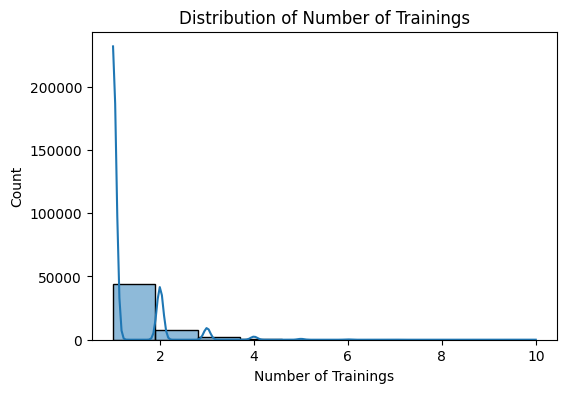

In [33]:
plt.figure(figsize=(6, 4))
sns.histplot(train_df["no_of_trainings"], bins=10, kde=True)
plt.title("Distribution of Number of Trainings")
plt.xlabel("Number of Trainings")
plt.ylabel("Count")
plt.show()

In [38]:
train_df["no_of_trainings"].skew()

np.float64(3.445433937567454)

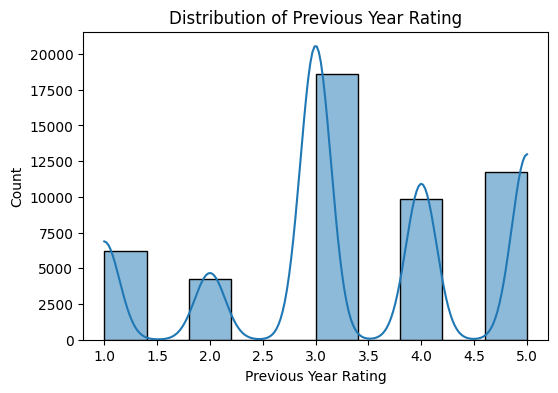

In [34]:
plt.figure(figsize=(6, 4))
sns.histplot(train_df["previous_year_rating"].dropna(), bins=10, kde=True)
plt.title("Distribution of Previous Year Rating")
plt.xlabel("Previous Year Rating")
plt.ylabel("Count")
plt.show()

In [39]:
train_df[numerical_columns].skew()

,0
employee_id,-0.003128
no_of_trainings,3.445434
age,1.007432
previous_year_rating,-0.310638
length_of_service,1.738061
KPIs_met >80%,0.619909
awards_won?,6.338914
avg_training_score,0.451908
is_promoted,2.972339


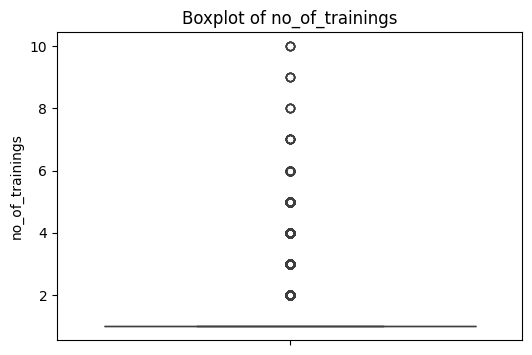

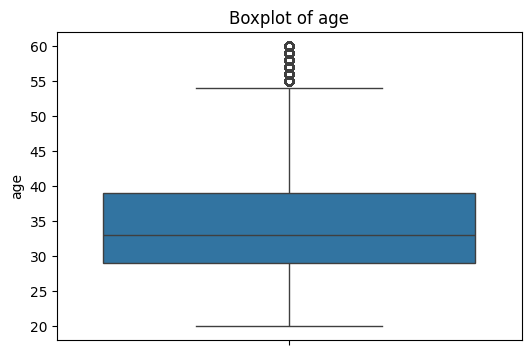

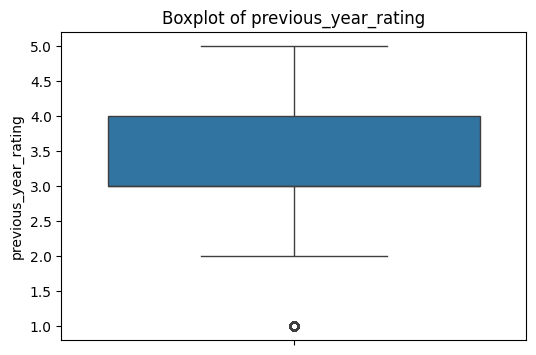

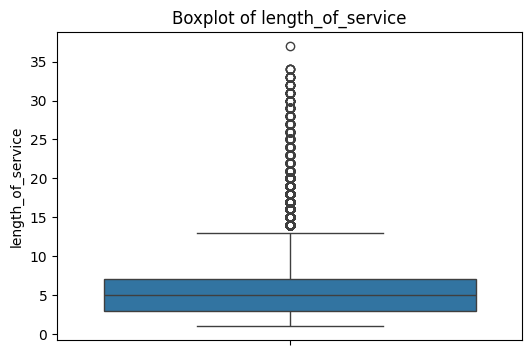

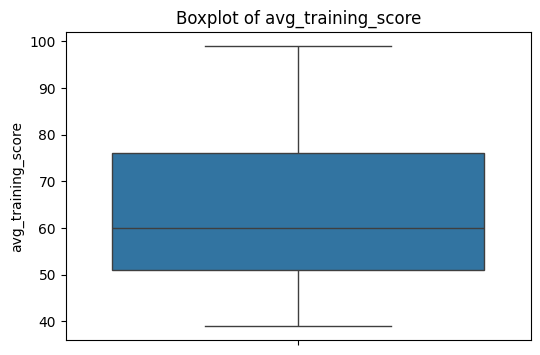

In [46]:
numerical_columns = [
    'no_of_trainings',
    'age',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score'
]

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=train_df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

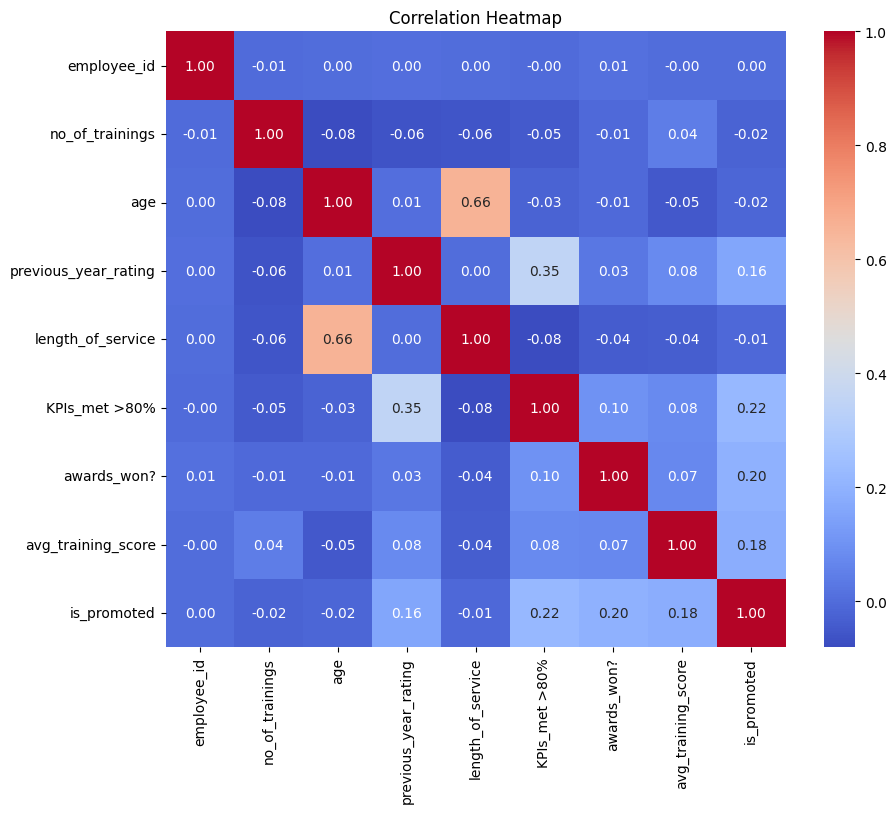

In [47]:
plt.figure(figsize=(10,8))

correlation = train_df.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

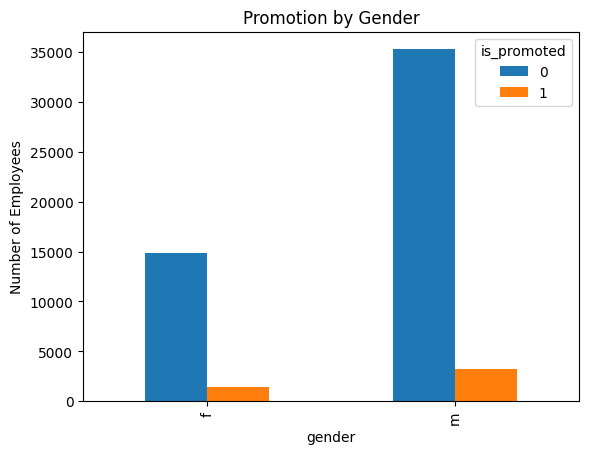

In [48]:
# This allows us to compare the number of promoted and non-promoted employees across genders.

pd.crosstab(train_df['gender'],
            train_df['is_promoted']).plot(kind='bar')

plt.title("Promotion by Gender")

plt.ylabel("Number of Employees")

plt.show()

In [49]:
train = train_df.copy()
test = test_df.copy()

print("Copies created successfully.")

Copies created successfully.


In [50]:
train = train.drop('employee_id', axis=1)
test_model = test.drop('employee_id', axis=1)

print("employee_id removed from model training data.")

employee_id removed from model training data.


In [51]:
print("Training Dataset Missing Values:\n")
print(train.isnull().sum())

print("\nTesting Dataset Missing Values:\n")
print(test_model.isnull().sum())

Training Dataset Missing Values:

department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

Testing Dataset Missing Values:

department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [52]:
train['education'].fillna(train['education'].mode()[0], inplace=True)
train['previous_year_rating'].fillna(train['previous_year_rating'].mode()[0], inplace=True)
print("Missing values handled in training dataset.")

Missing values handled in training dataset.


/tmp/ipykernel_1164/198489545.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['education'].fillna(train['education'].mode()[0], inplace=True)
/tmp/ipykernel_1164/198489545.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [53]:
test_model['education'].fillna(test_model['education'].mode()[0], inplace=True)

test_model['previous_year_rating'].fillna(test_model['previous_year_rating'].mode()[0], inplace=True)

print("Missing values handled in test dataset.")

Missing values handled in test dataset.


/tmp/ipykernel_1164/991044936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_model['education'].fillna(test_model['education'].mode()[0], inplace=True)
/tmp/ipykernel_1164/991044936.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [54]:
print(train.isnull().sum())

print("\n")

print(test_model.isnull().sum())

department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64


department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64


In [57]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    train[column] = le.fit_transform(train[column])
    test_model[column] = le.transform(test_model[column])

    label_encoders[column] = le

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [58]:
X = train.drop('is_promoted', axis=1)

y = train['is_promoted']

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (54808, 12)
Target Shape : (54808,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape :", X_train.shape)
print("Validation Features Shape :", X_valid.shape)
print("Training Target Shape :", y_train.shape)
print("Validation Target Shape :", y_valid.shape)

Training Features Shape : (43846, 12)
Validation Features Shape : (10962, 12)
Training Target Shape : (43846,)
Validation Target Shape : (10962,)


In [ ]:
# Decision Tree
# Random Forest

# These algorithms do not require feature scaling.

# When we train Logistic Regression, we will apply scaling because it performs better with standardized numerical features.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [61]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [62]:
lr_pred = lr_model.predict(X_valid_scaled)

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_valid, lr_pred))
print("Precision:", precision_score(y_valid, lr_pred))
print("Recall   :", recall_score(y_valid, lr_pred))
print("F1 Score :", f1_score(y_valid, lr_pred))


Accuracy : 0.9176245210727969
Precision: 0.6371681415929203
Recall   : 0.07708779443254818
F1 Score : 0.13753581661891118


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, lr_pred)
print(cm)

[[9987   41]
 [ 862   72]]


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, lr_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     10028
           1       0.64      0.08      0.14       934

    accuracy                           0.92     10962
   macro avg       0.78      0.54      0.55     10962
weighted avg       0.90      0.92      0.89     10962



In [69]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


In [70]:
dt_pred = dt_model.predict(X_valid)

In [71]:
print("Accuracy :", accuracy_score(y_valid, dt_pred))
print("Precision:", precision_score(y_valid, dt_pred))
print("Recall   :", recall_score(y_valid, dt_pred))
print("F1 Score :", f1_score(y_valid, dt_pred))

Accuracy : 0.8883415435139573
Precision: 0.36936936936936937
Recall   : 0.43897216274089934
F1 Score : 0.40117416829745595


In [72]:
cm = confusion_matrix(y_valid, dt_pred)

print(cm)

[[9328  700]
 [ 524  410]]


In [73]:
print(classification_report(y_valid, dt_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94     10028
           1       0.37      0.44      0.40       934

    accuracy                           0.89     10962
   macro avg       0.66      0.68      0.67     10962
weighted avg       0.90      0.89      0.89     10962



In [74]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [75]:
rf_pred = rf_model.predict(X_valid)

In [76]:

print("Accuracy :", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred))
print("Recall   :", recall_score(y_valid, rf_pred))
print("F1 Score :", f1_score(y_valid, rf_pred))

Accuracy : 0.9360518153621602
Precision: 0.8675078864353313
Recall   : 0.2944325481798715
F1 Score : 0.4396482813749001


In [77]:
cm = confusion_matrix(y_valid, rf_pred)

print(cm)

[[9986   42]
 [ 659  275]]


In [78]:

print(classification_report(y_valid, rf_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.87      0.29      0.44       934

    accuracy                           0.94     10962
   macro avg       0.90      0.65      0.70     10962
weighted avg       0.93      0.94      0.92     10962



In [80]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_valid, lr_pred),
        accuracy_score(y_valid, dt_pred),
        accuracy_score(y_valid, rf_pred)
    ],
    'Precision': [
        precision_score(y_valid, lr_pred),
        precision_score(y_valid, dt_pred),
        precision_score(y_valid, rf_pred)
    ],
    'Recall': [
        recall_score(y_valid, lr_pred),
        recall_score(y_valid, dt_pred),
        recall_score(y_valid, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_valid, lr_pred),
        f1_score(y_valid, dt_pred),
        f1_score(y_valid, rf_pred)
    ]
})

results = results.sort_values(
    by='F1 Score',
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.936052,0.867508,0.294433,0.439648
1,Decision Tree,0.888342,0.369369,0.438972,0.401174
0,Logistic Regression,0.917625,0.637168,0.077088,0.137536


In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [10, 20, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4]

}

In [83]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    param_grid=param_grid,

    scoring='f1',

    cv=5,

    n_jobs=-1,

    verbose=2

)

In [84]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [85]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [86]:
best_rf = grid_search.best_estimator_

In [87]:
best_pred = best_rf.predict(X_valid)

In [88]:
print("Accuracy :", accuracy_score(y_valid, best_pred))

print("Precision:", precision_score(y_valid, best_pred))

print("Recall   :", recall_score(y_valid, best_pred))

print("F1 Score :", f1_score(y_valid, best_pred))

Accuracy : 0.9171683999270206
Precision: 0.5174731182795699
Recall   : 0.41220556745182013
F1 Score : 0.45887961859356374


In [89]:
print(classification_report(y_valid, best_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     10028
           1       0.52      0.41      0.46       934

    accuracy                           0.92     10962
   macro avg       0.73      0.69      0.71     10962
weighted avg       0.91      0.92      0.91     10962



In [90]:
cm = confusion_matrix(y_valid, best_pred)

print(cm)

[[9669  359]
 [ 549  385]]


In [91]:
print("Random Forest F1 Score (Before Tuning):",
      f1_score(y_valid, rf_pred))

print("Random Forest F1 Score (After Tuning):",
      f1_score(y_valid, best_pred))

Random Forest F1 Score (Before Tuning): 0.4396482813749001
Random Forest F1 Score (After Tuning): 0.45887961859356374


In [92]:

test_predictions = best_rf.predict(test_model)

print("Prediction Completed.")

Prediction Completed.


In [93]:
# First 10 Predictions

print(test_predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [95]:
submission = pd.read_csv("/content/sample_submission_M0L0uXE.csv")

submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [96]:
submission['is_promoted'] = test_predictions

submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [97]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [98]:
submission.head(10)

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0
5,46232,0
6,54542,0
7,67269,0
8,66174,0
9,76303,0
